In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 80)

In [2]:
data_v1=pd.read_csv('data/Train-test-dataset_Ver1.csv')
# data_v3=pd.read_csv('data/Train-test-dataset_Ver3.csv')
data_v3=pd.read_csv('data/Train-test-dataset_Ver3_iterative.csv')

In [3]:
data=data_v3.copy()

In [4]:
def handle_missing_values(df):
    """
    处理DataFrame中的缺失值。
    
    参数:
        df (pd.DataFrame): 输入的原始DataFrame
    
    返回:
        pd.DataFrame: 缺失值处理后的DataFrame
    """
    df_clean = df.copy()

    for col in df_clean.columns:
        if df_clean[col].isnull().sum() > 0:
            if pd.api.types.is_numeric_dtype(df_clean[col]):
                # 数值型：用中位数填充
                median_val = df_clean[col].median()
                df_clean[col].fillna(median_val, inplace=True)
            elif pd.api.types.is_object_dtype(df_clean[col]):
                # 类别型：用众数（mode）填充，如果众数不存在则用 'Unknown'
                mode_vals = df_clean[col].mode()
                if not mode_vals.empty:
                    df_clean[col].fillna(mode_vals[0], inplace=True)
                else:
                    df_clean[col].fillna('Unknown', inplace=True)
            else:
                # 其他类型可选处理，如时间类型等
                df_clean[col].fillna('Missing', inplace=True)
    
    return df_clean

In [5]:
data = handle_missing_values(data)

In [ ]:
data.to_csv('data/Train-test-dataset_Ver3_Cleaned.csv', index=False)

In [4]:
data['have_stone'] = data['have_stone'].astype(int)

# 分离特征和标签
X = data.drop(columns=['have_stone'])  # 特征
y = data['have_stone']  # 标签

# 查看结果
print("特征:")
print(X.head())
print("\n标签:")
print(y.head())

特征:
   Cystatin-C  Creatinine  Serum_Uric_acid  Serum_Urea  Uric_RBC  Uric_WBC  \
0        0.58        77.7            300.0        4.37       1.0       3.0   
1        0.77        58.0            316.0        7.80       4.0       1.0   
2        0.95        79.0            455.0        5.40       1.0       0.0   
3        0.80        83.0            486.0        4.10      13.0       1.0   
4        0.85        59.0            256.0        5.20       1.0       1.0   

   Uric_PH  Uric_specific_gravity  Uric_conductivity  Uric_epithelium  \
0      6.0                  1.017               16.0              1.0   
1      6.5                  1.028               22.0              0.0   
2      5.0                  1.020               26.0              0.0   
3      6.0                  1.021               13.0              0.0   
4      6.5                  1.014               15.0              0.0   

   Uric_bacteria   RBC  RDW(SD)  RDW(CV)   HCT   MCHC   MCH   MCV     HB  \
0           

In [9]:
# 划分训练集和测试集
import cupy as cp
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score, roc_curve
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)
# 将数据移动到 GPU
X_train_gpu = cp.asarray(X_train)
y_train_gpu = cp.asarray(y_train)
X_test_gpu = cp.asarray(X_test)
y_test_gpu = cp.asarray(y_test)
model_xgb = XGBClassifier(max_depth=5,
                              learning_rate=0.05,
                              n_estimators=200,
                              objective='binary:logistic',
                              booster='gbtree',
                              gamma=0.2,
                              min_child_weight=2,
                              subsample=0.8,
                              colsample_bytree=1,
                              reg_alpha=1,
                              reg_lambda=1.5,
                              scale_pos_weight=5,
                              seed=42
                              )
model_xgb.fit(X_train, y_train)
# 进行预测
y_pred = model_xgb.predict(X_test)

# 评估模型
# rmse = root_mean_squared_error(y_test, y_pred, squared=False)
# print(f"RMSE: {rmse}")

# 保存模型
model_xgb.save_model('xgb_model.model')

d:\Cache\Conda\envs\EHR\lib\site-packages\xgboost\core.py:158: UserWarning: [21:13:21] WARNING: D:\bld\xgboost-split_1738880195977\work\src\c_api\c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)


In [ ]:
# 定义参数网格
# from sklearn.model_selection import GridSearchCV


# param_grid = {
#     'max_depth': [3, 4, 5, 6],
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'n_estimators': [50, 100, 200],
#     'subsample': [0.6, 0.7, 0.8, 0.9],
#     'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
#     'min_child_weight': [1, 2, 3],
#     'gamma': [0, 0.1, 0.2],
#     'reg_alpha': [0, 0.1, 0.2],
#     'reg_lambda': [0.5, 1, 1.5]
# }

# # 初始化 XGBoost 分类器
# model_xgb = XGBClassifier(objective='binary:logistic', booster='gbtree', random_state=42,device='cuda')

# # 初始化网格搜索对象，以 ROC AUC 为评分标准
# grid_search = GridSearchCV(estimator=model_xgb, param_grid=param_grid, cv=5, scoring='roc_auc', verbose=2, n_jobs=-1)

# # 执行网格搜索
# grid_search.fit(X_train_gpu.get(), y_train_gpu.get())

# 输出最优参数和对应 ROC AUC 值
# print("最优参数:", grid_search.best_params_)
# print("最优 ROC AUC 值:", grid_search.best_score_)

# 使用最优参数创建模型并训练
# best_model = grid_search.best_estimator_
# best_model.fit(X_train, y_train)

# 进行预测
# y_pred = best_model.predict(X_test)
# y_pred_proba = best_model.predict_proba(X_test)[:, 1]  # 用于计算 ROC AUC

# # 评估模型
# roc_auc = roc_auc_score(y_test, y_pred_proba)
# print(f"测试集 ROC AUC: {roc_auc}")

# # 保存模型
# best_model.save_model('xgb_model.model')

In [7]:
from metrics_custom import calculate_metrics, plot_roc_pr_curves
y_pred_proba = model_xgb.predict_proba(X_test)[:, 1]  # 用于计算 ROC AUC
metrics = calculate_metrics(y_test, y_pred_proba, y_pred)
print(metrics)
plot_roc_pr_curves(y_test, y_pred_proba, y_pred)

AttributeError: 'Series' object has no attribute 'predict_proba'

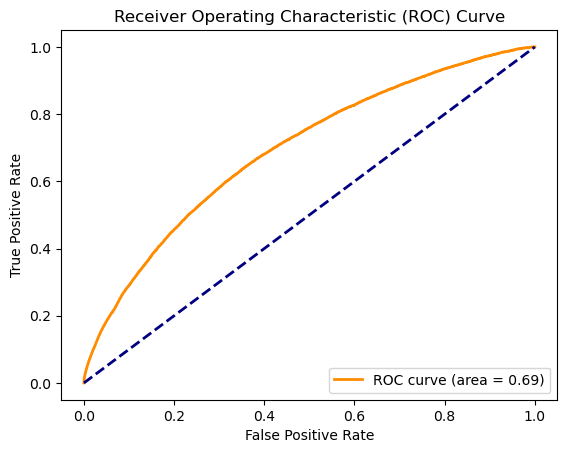

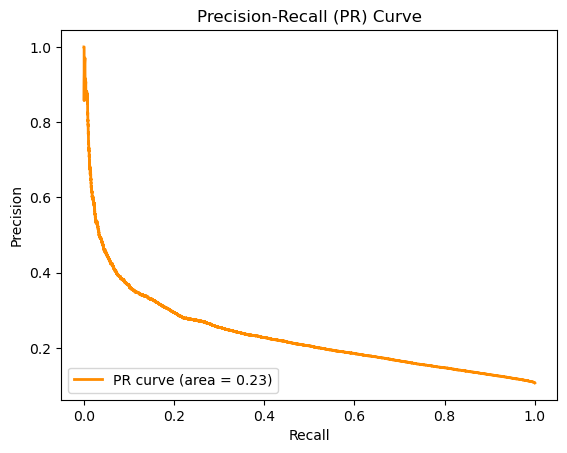

AUROC: 0.6935
AUPRC: 0.2346
F1 Score: 0.2803
Metrics:
AUC Score: 0.6935, 95% CI: (0.6927, 0.6942)
Accuracy: 0.8223
Sensitivity: 0.3237
Specificity: 0.8819
PPV: 0.2471
NPV: 0.9159
F1 Score: 0.2803


In [11]:
# 绘制 ROC 和 PR 曲线
y_pred = model_xgb.predict(X_test)
y_pred_prob = model_xgb.predict_proba(X_test)[:, 1]
plot_roc_pr_curves(y_test, y_pred_prob, y_pred)

# 计算评估指标
metrics = calculate_metrics(model_xgb, X_test, y_test)
# print(f"评估指标:{metrics}")
print("Metrics:")
print(f"AUC Score: {metrics[0]:.4f}, 95% CI: ({metrics[1]:.4f}, {metrics[2]:.4f})")
print(f"Accuracy: {metrics[3]:.4f}")
print(f"Sensitivity: {metrics[4]:.4f}")
print(f"Specificity: {metrics[5]:.4f}")
print(f"PPV: {metrics[6]:.4f}")
print(f"NPV: {metrics[7]:.4f}")
print(f"F1 Score: {metrics[8]:.4f}")